# APS Failure at Scania Trucks: EDA и эксперименты

Стартовый ноутбук проекта. Он проверяет загрузку UCI-данных, фиксирует главный дисбаланс классов и связывает разведочный анализ с общим training pipeline из `src/`.

Детальные сценарии вынесены отдельно:

- `02_data_quality_deep_dive.ipynb` — пропуски, стабильность train/test, row-level качество.
- `03_feature_signal_analysis.ipynb` — одномерная сигнальность признаков, missingness-as-signal, корреляции.
- `04_model_diagnostics_and_error_analysis.ipynb` — пороги, стоимость ошибок, разбор FP/FN.


In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.cache' / 'matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(PROJECT_ROOT))

from src.aps_failure.data import load_dataset, make_data_quality_report

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)

train_path = PROJECT_ROOT / 'data/raw/aps_failure_training_set.csv'
test_path = PROJECT_ROOT / 'data/raw/aps_failure_test_set.csv'
x_train, y_train = load_dataset(train_path)
x_test, y_test = load_dataset(test_path)
print(f'train: {x_train.shape}, test: {x_test.shape}')


train: (60000, 170), test: (16000, 170)


## Размеры, классы и базовое качество

APS-positive — редкий класс. Поэтому обычная accuracy почти бесполезна: важнее recall, precision-recall AUC и бизнес-стоимость ошибок.


In [2]:
quality = make_data_quality_report(x_train, y_train, x_test, y_test)
summary = pd.DataFrame(
    {
        'train': [len(x_train), x_train.shape[1], int(y_train.sum()), float(y_train.mean()), float(x_train.isna().mean().mean())],
        'test': [len(x_test), x_test.shape[1], int(y_test.sum()), float(y_test.mean()), float(x_test.isna().mean().mean())],
    },
    index=['rows', 'features', 'positive_rows', 'positive_rate', 'missing_cell_ratio'],
)
summary


,train,test
rows,60000.000000,16000.000000
features,170.000000,170.000000
positive_rows,1000.000000,375.000000
positive_rate,0.016667,0.023438
missing_cell_ratio,0.083335,0.084074


In [3]:
class_balance = pd.concat(
    [
        y_train.value_counts().rename(index={0: 'neg', 1: 'pos'}).rename('train_count'),
        y_train.value_counts(normalize=True).rename(index={0: 'neg', 1: 'pos'}).rename('train_share'),
        y_test.value_counts().rename(index={0: 'neg', 1: 'pos'}).rename('test_count'),
        y_test.value_counts(normalize=True).rename(index={0: 'neg', 1: 'pos'}).rename('test_share'),
    ],
    axis=1,
).loc[['neg', 'pos']]
class_balance


,train_count,train_share,test_count,test_share
class,,,,
neg,59000,0.983333,15625,0.976562
pos,1000,0.016667,375,0.023438


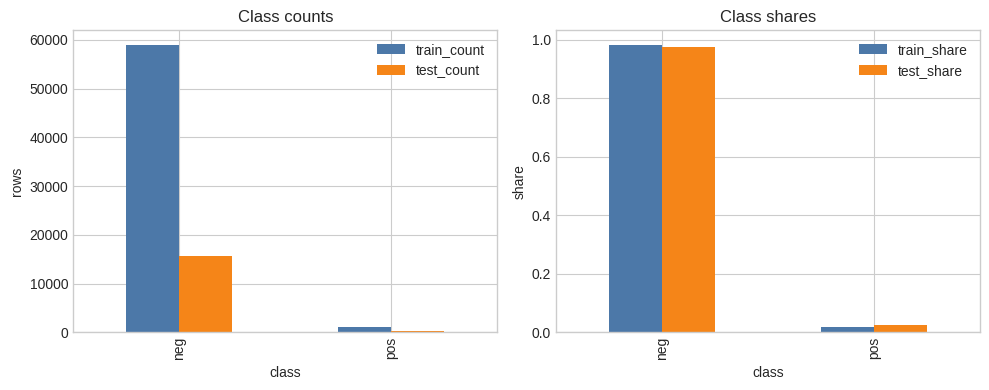

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
class_balance[['train_count', 'test_count']].plot(kind='bar', ax=axes[0], color=['#4c78a8', '#f58518'])
axes[0].set_title('Class counts')
axes[0].set_ylabel('rows')
class_balance[['train_share', 'test_share']].plot(kind='bar', ax=axes[1], color=['#4c78a8', '#f58518'])
axes[1].set_title('Class shares')
axes[1].set_ylabel('share')
plt.tight_layout()


## Самые проблемные признаки по пропускам

В датасете много анонимизированных сенсорных признаков, часть из них почти всегда отсутствует. Это важно для выбора imputing-стратегии и интерпретации модели.


In [5]:
missing = pd.DataFrame(
    {
        'train_missing': x_train.isna().mean(),
        'test_missing': x_test.isna().mean(),
    }
)
missing['abs_delta'] = (missing['train_missing'] - missing['test_missing']).abs()
missing.sort_values('train_missing', ascending=False).head(25)


,train_missing,test_missing,abs_delta
br_000,0.821067,0.820562,0.000504
bq_000,0.812033,0.811312,0.000721
bp_000,0.795667,0.795063,0.000604
bo_000,0.772217,0.773500,0.001283
ab_000,0.772150,0.772687,0.000537
cr_000,0.772150,0.772687,0.000537
bn_000,0.733483,0.732062,0.001421
bm_000,0.659150,0.659125,0.000025
bl_000,0.454617,0.451625,0.002992
bk_000,0.383900,0.380875,0.003025


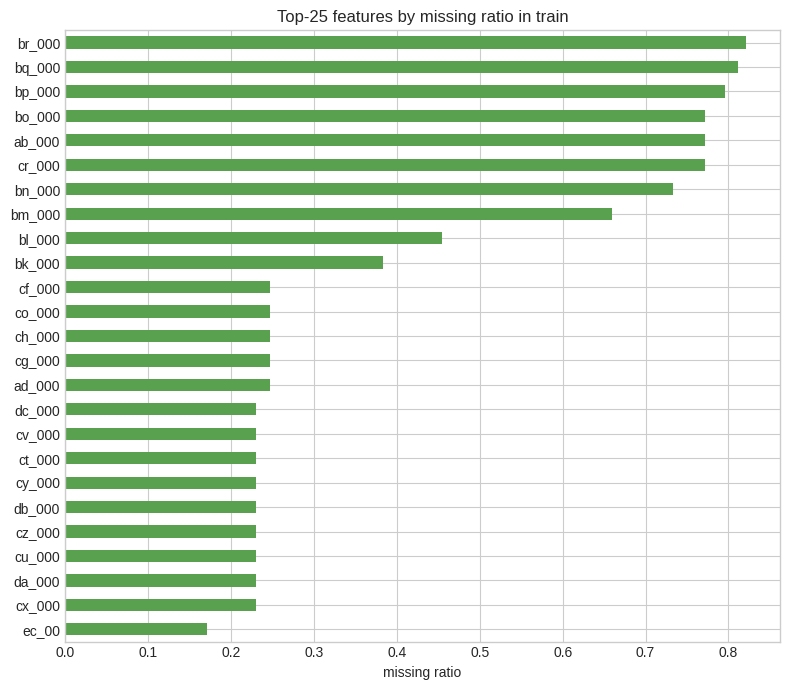

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
missing.sort_values('train_missing', ascending=False).head(25).sort_values('train_missing')['train_missing'].plot(
    kind='barh', ax=ax, color='#59a14f'
)
ax.set_title('Top-25 features by missing ratio in train')
ax.set_xlabel('missing ratio')
plt.tight_layout()


## Связь с обучением

Полный запуск оставлен закомментированным, чтобы ноутбук не переобучал модели случайно. Если нужно пересобрать артефакты, раскомментируйте последнюю строку.


In [7]:
from src.aps_failure.train import run_training

# summary = run_training(PROJECT_ROOT / 'configs/default.yaml')


In [8]:
metrics_path = PROJECT_ROOT / 'artifacts/metrics.json'
if metrics_path.exists():
    with metrics_path.open(encoding='utf-8') as file:
        metrics = json.load(file)
    runs = pd.DataFrame(
        {
            'model': row['model'],
            'threshold': row['threshold'],
            'val_pr_auc': row['validation']['average_precision'],
            'val_recall': row['validation']['recall'],
            'val_cost': row['validation']['total_cost'],
            'test_pr_auc': row['test']['average_precision'],
            'test_recall': row['test']['recall'],
            'test_cost': row['test']['total_cost'],
        }
        for row in metrics['runs']
    ).sort_values('val_cost')
    runs
else:
    print('metrics.json пока не найден. Запустите training pipeline, если нужны результаты моделей.')


Дальше стоит смотреть отдельные ноутбуки: они глубже разбирают качество данных, полезность признаков и ошибки лучшей модели.
